In [ ]:
# ⚠️ REPLACE THIS with your own roll number, e.g. 03 for roll no. AP22110011603
ROLL_NUMBER = 0o3

print(f"Using random seed = {ROLL_NUMBER}")

Using random seed = 3


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else None

In [ ]:
iris = load_iris()

X = iris.data                     # features: sepal/petal length & width
y = iris.target                   # target: 0 = setosa, 1 = versicolor, 2 = virginica
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]

print("Shape of dataset:", df.shape)
print("\nClass distribution:")
print(df['species'].value_counts())

df.head(10)

Shape of dataset: (150, 5)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


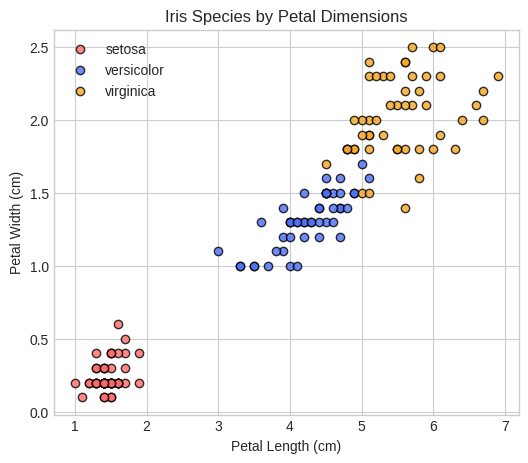

In [ ]:
# Quick visual check: petal length vs petal width, coloured by species
plt.figure(figsize=(6, 5))
colors = ['#FF6B6B', '#4C6EF5', '#F5A623']
for i, species in enumerate(target_names):
    subset = df[df['species'] == species]
    plt.scatter(subset['petal length (cm)'], subset['petal width (cm)'],
                label=species, color=colors[i], edgecolor='k', alpha=0.8)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Species by Petal Dimensions')
plt.legend()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=ROLL_NUMBER, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Training samples: 105
Testing samples : 45


In [ ]:
# Take the first test flower
sample = X_test[0]
true_label = target_names[y_test[0]]

# Compute Euclidean distance from this sample to every training point
distances = np.sqrt(np.sum((X_train - sample) ** 2, axis=1))

# Find indices of the 5 nearest neighbours
k = 3
nearest_idx = np.argsort(distances)[:k]
nearest_labels = [target_names[y_train[i]] for i in nearest_idx]

print("Test flower measurements:", dict(zip(feature_names, sample.round(2))))
print("True species:", true_label)
print(f"\n{k} nearest neighbours' species:", nearest_labels)

# Majority vote
from collections import Counter
vote = Counter(nearest_labels).most_common(1)[0][0]
print(f"\nMajority vote prediction: {vote}")
print("Correct!" if vote == true_label else "Incorrect!")

Test flower measurements: {'sepal length (cm)': np.float64(4.4), 'sepal width (cm)': np.float64(3.2), 'petal length (cm)': np.float64(1.3), 'petal width (cm)': np.float64(0.2)}
True species: setosa

3 nearest neighbours' species: [np.str_('setosa'), np.str_('setosa'), np.str_('setosa')]

Majority vote prediction: setosa
Correct!


In [ ]:
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Predictions generated for", len(y_pred), "test samples.")

Predictions generated for 45 test samples.


In [ ]:
results = pd.DataFrame(X_test, columns=feature_names)
results['Actual']    = [target_names[i] for i in y_test]
results['Predicted'] = [target_names[i] for i in y_pred]
results['Result']    = np.where(results['Actual'] == results['Predicted'], 'Correct', 'Wrong')

correct = results[results['Result'] == 'Correct'].reset_index(drop=True)
wrong   = results[results['Result'] == 'Wrong'].reset_index(drop=True)

print("=" * 70)
print(f"CORRECT PREDICTIONS ({len(correct)} out of {len(results)})")
print("=" * 70)
print(correct.to_string(index=True))

print("\n" + "=" * 70)
print(f"WRONG PREDICTIONS ({len(wrong)} out of {len(results)})")
print("=" * 70)
if len(wrong) > 0:
    print(wrong.to_string(index=True))
else:
    print("None — every test sample was classified correctly for this split/seed.")

CORRECT PREDICTIONS (43 out of 45)
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)      Actual   Predicted   Result
0                 4.4               3.2                1.3               0.2      setosa      setosa  Correct
1                 6.2               3.4                5.4               2.3   virginica   virginica  Correct
2                 5.1               3.8                1.5               0.3      setosa      setosa  Correct
3                 5.7               2.9                4.2               1.3  versicolor  versicolor  Correct
4                 6.4               3.2                4.5               1.5  versicolor  versicolor  Correct
5                 7.7               3.0                6.1               2.3   virginica   virginica  Correct
6                 4.4               2.9                1.4               0.2      setosa      setosa  Correct
7                 6.2               2.2                4.5               1.5  versico

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)\n")

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=[f"Actual {n}" for n in target_names],
                          columns=[f"Pred {n}" for n in target_names])
print(cm_df)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.9556  (95.56%)

Confusion Matrix:
                   Pred setosa  Pred versicolor  Pred virginica
Actual setosa               15                0               0
Actual versicolor            0               13               2
Actual virginica             0                0              15

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.87      0.93        15
   virginica       0.88      1.00      0.94        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



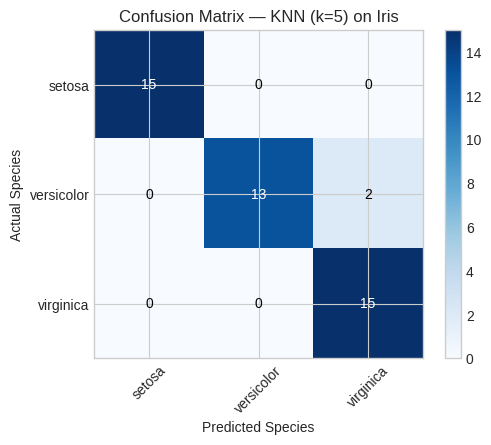

In [ ]:
# Visualise the confusion matrix
plt.figure(figsize=(5.5, 4.5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix — KNN (k=5) on Iris')
plt.colorbar()
tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                  color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

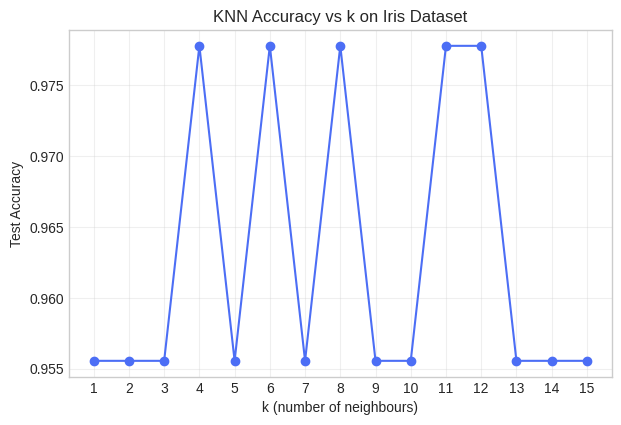

Best k for this split: 4  (Accuracy: 0.9778)


In [ ]:
k_values = range(1, 16)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracies.append(acc)

plt.figure(figsize=(7, 4.5))
plt.plot(list(k_values), accuracies, marker='o', color='#4C6EF5')
plt.xlabel('k (number of neighbours)')
plt.ylabel('Test Accuracy')
plt.title('KNN Accuracy vs k on Iris Dataset')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

best_k = list(k_values)[int(np.argmax(accuracies))]
print(f"Best k for this split: {best_k}  (Accuracy: {max(accuracies):.4f})")

1)Re-run the notebook with **your own roll number** as the seed (Section 4) — do NOT use 42.


i run all the cells by using roll number, e.g. 03 for roll no. AP22110011603 instead of 42

2. Try k = 1, k = 3, and k = 9. How does the number of wrong predictions change?
ans)
k	Wrong Predictions	Accuracy
k = 1	2	95.56%
k = 3	2	95.56%
k = 9	2	95.56%
the number of wrong predictions remains 2 for k = 1, k = 3, and k = 9. Therefore, the accuracy remains 95.56% for all three values of k.

3. Change the metric from 'euclidean' to 'manhattan'. Does accuracy change?

Using k = 5:

Euclidean distance → 95.56% accuracy, 2 wrong predictions.
Manhattan distance → 95.56% accuracy, 2 wrong predictions.
No, the accuracy does not change. Both Euclidean and Manhattan distance give 95.56% accuracy for this seed.

4)Which two species are most often confused with each other, and why?

The two species most often confused are Versicolor and Virginica.

The confusion matrix shows that:

2 Versicolor flowers were predicted as Virginica.
No Setosa flowers were misclassified.

Reason: Versicolor and Virginica have similar measurements, particularly their petal length and petal width. Because their feature values overlap, KNN can sometimes confuse these two species.